<a href="https://colab.research.google.com/github/Alenkar14/urban-traffic-dynamics-seir/blob/main/simulacion_trafico_seir.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

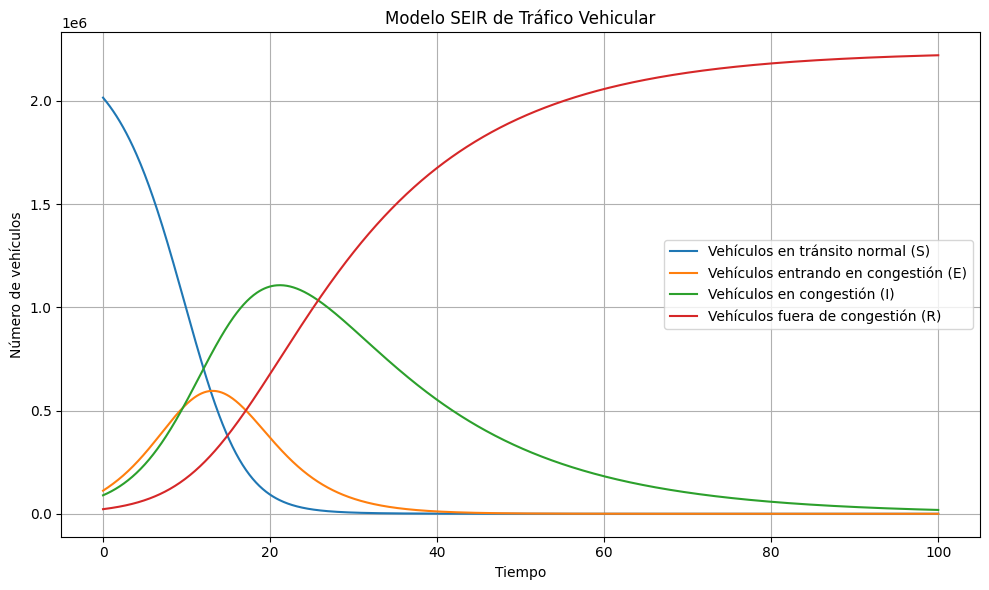

In [1]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# Parámetros poblacionales y tasas
N = 2240000
beta = 0.6
sigma = 0.2
gamma = 0.057

# Condiciones iniciales
S0 = 2016000
E0 = 112000
I0 = 89600
R0 = 22400

y0 = [S0, E0, I0, R0]

# Vector de tiempo (100 minutos, 1000 puntos para suavidad)
t = np.linspace(0, 100, 1000)

# Definición del sistema de ecuaciones diferenciales SEIR
def seir(y, t, N, beta, sigma, gamma):
    S, E, I, R = y
    dSdt = -beta * S * I / N
    dEdt = beta * S * I / N - sigma * E
    dIdt = sigma * E - gamma * I
    dRdt = gamma * I
    return [dSdt, dEdt, dIdt, dRdt]

# Integración del modelo (Resolución de las ODEs)
sol = odeint(seir, y0, t, args=(N, beta, sigma, gamma))
S, E, I, R = sol.T

# Visualización
plt.figure(figsize=(10,6))
plt.plot(t, S, label='Vehículos en tránsito normal (S)')
plt.plot(t, E, label='Vehículos entrando en congestión (E)')
plt.plot(t, I, label='Vehículos en congestión (I)')
plt.plot(t, R, label='Vehículos fuera de congestión (R)')

plt.xlabel('Tiempo')
plt.ylabel('Número de vehículos')
plt.title('Modelo SEIR de Tráfico Vehicular')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()